In [1]:
import json
from itertools import product
from pathlib import Path

import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from loguru import logger
from torchmetrics.classification import BinaryF1Score
from tqdm import tqdm

from fast_boolean_analysis import FourierSeries, fourier_expand
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    LBFFromNN,
    LBFFromSpinSystem,
    SignalKind,
    SignSignalKind,
)
from pytorchtools import EarlyStopping
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from spin_nn import FC1SpinNN, SpinNN
from utils import get_abslargest_terms, make_unpacked_configurations
from multi_nn_2023_03_06 import (
    ground_state_cache_dir,
    experiment_dir,
    nn_checkpoints_dir,
    model_evaluation_dir,
    nn_terms_dir,
    system_terms_dir,
    eps_trains,
    J2s,
    signal_kinds,
    lattices,
)
import seaborn as sns


/vol/tcm10/ischurov/.conda/envs/latsym2/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /vol/tcm10/ischurov/.conda/envs/latsym2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warn(f"Failed to load image Python extension: {e}")
2023-03-08 09:54:43.743 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-03-08 09:54:43.745 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-03-08 09:54:43.789 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
%matplotlib inline

In [47]:
def json_dir_to_df(dir: Path) -> pd.DataFrame:
    return pd.DataFrame([json.loads(file.read_text()) for file in dir.glob("*")])

name_to_lattice = {lattice.get_cache_id(): lattice for lattice in lattices}

In [9]:
model_evaluation = json_dir_to_df(model_evaluation_dir)
nn_terms = json_dir_to_df(nn_terms_dir)
system_terms = json_dir_to_df(system_terms_dir)


In [5]:
model_evaluation


,J2,eps_train,accuracy_test,sign_overlap_test,f1_test,epoch,lattice,train_size,path,signal_kind
0,0.5,0.005,0.646039,0.472055,0.642912,301,SquareLattice6x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
1,0.4,0.010,0.989077,0.985053,0.988855,301,TriangleLattice6x4,27042,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
2,0.4,0.020,0.981577,0.979323,0.979961,301,SquareLattice6x4,54083,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
3,0.8,0.005,0.546301,0.131796,0.518617,301,KagomeLattice2x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
4,0.2,0.020,0.999190,0.998509,0.999188,301,KagomeLattice2x4,54083,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
...,...,...,...,...,...,...,...,...,...,...
94,0.0,0.005,0.973358,0.959064,0.972863,301,TriangleLattice6x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
95,0.7,0.010,0.999041,0.999537,0.999031,301,SquareLattice6x4,27042,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
96,0.1,0.020,0.998332,0.996411,0.998293,301,TriangleLattice6x4,54083,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
97,0.5,0.005,0.964900,0.939809,0.963771,366,TriangleLattice6x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign


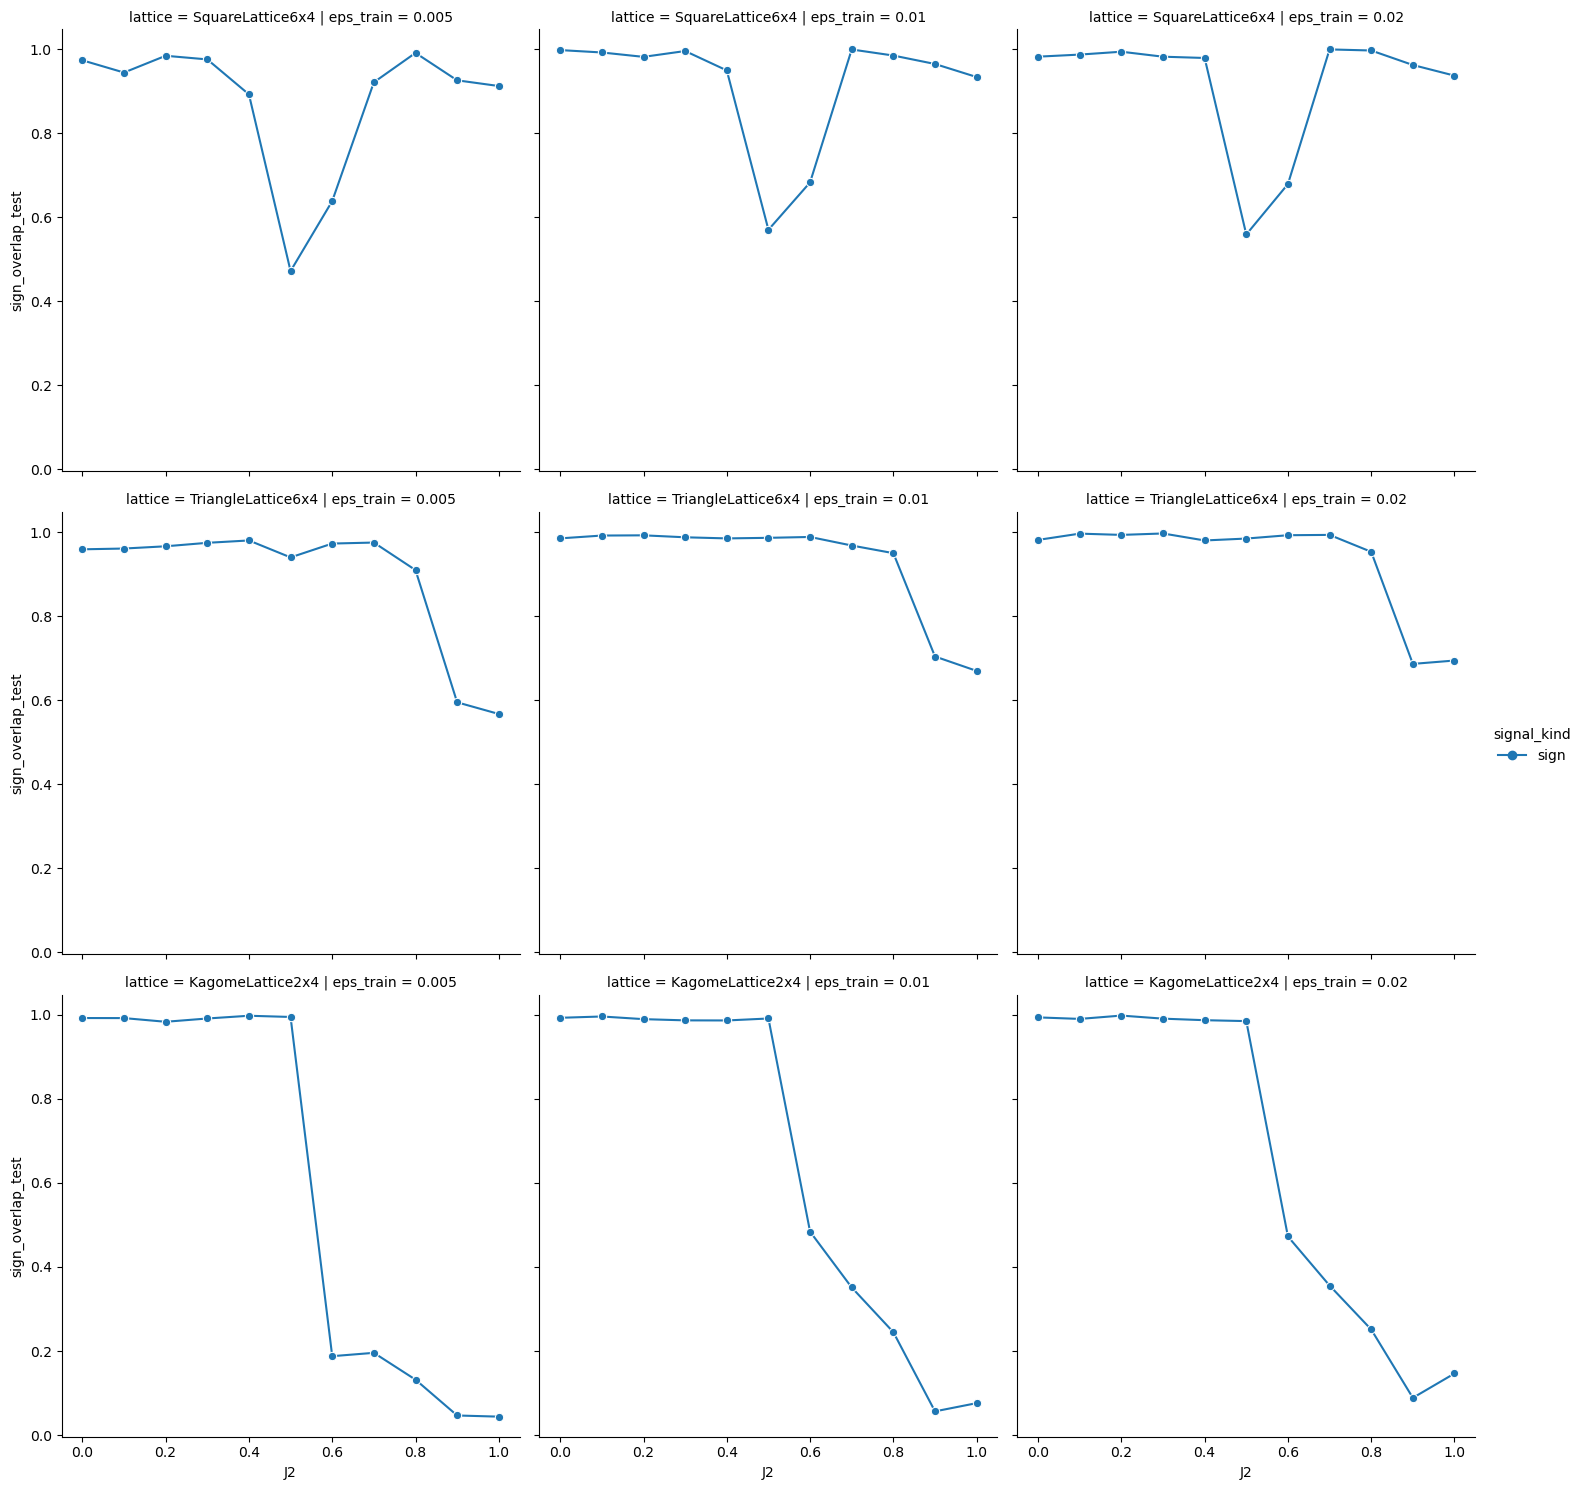

In [11]:
sns.relplot(
    model_evaluation,
    x="J2",
    y="sign_overlap_test",
    row="lattice",
    col="eps_train",
    hue="signal_kind",
    kind="line",
    style="signal_kind",
    markers=["o"],
)


In [18]:
nn_terms["success"].all()


True

In [29]:
terms = pd.concat([nn_terms, system_terms.assign(eps_train="ground_true")])


In [30]:
terms

,f1,sign_overlap,accuracy,success,terms,total_hamming_weight,rel_fourier_weight,largest_terms,largest_coeffs,lattice,J2,eps_train
0,0.782205,0.900776,0.800004,True,1559,10122,0.199774,"[5921382, 10855833, 16777215, 0, 1, 16777214, ...","[311.267578125, 311.267578125, -53.0419921875,...",SquareLattice6x4,0.5,0.005
1,0.983454,0.889582,0.983644,True,1,12,0.150808,[10855833],[638.59814453125],TriangleLattice6x4,0.4,0.01
2,0.990527,0.920337,0.990576,True,1,12,0.155162,[10855833],[647.75146484375],SquareLattice6x4,0.4,0.02
3,0.828022,0.451951,0.800007,True,6026,24356,0.182387,"[16777215, 0, 16777207, 8, 16777211, 4, 256, 1...","[82.005859375, 82.005859375, 61.2744140625, 61...",KagomeLattice2x4,0.8,0.005
4,0.998302,0.998795,0.998305,True,1,8,0.160089,[16608090],[-657.9560546875],KagomeLattice2x4,0.2,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...
28,1.000000,1.000000,1.000000,True,1,12,0.161180,[10855833],[660.1943359375],SquareLattice6x4,0.2,ground_true
29,0.799881,0.983510,0.800012,True,19953,224878,0.211453,"[16303665, 16134540, 473550, 642675, 4834931, ...","[32.0556640625, 32.0556640625, 32.0556640625, ...",KagomeLattice2x4,0.8,ground_true
30,0.838231,0.978129,0.838024,True,1,12,0.073666,[11184844],[446.3232421875],SquareLattice6x4,0.9,ground_true
31,0.799808,0.969973,0.800085,True,9595,107076,0.206830,"[5921382, 10855833, 12829605, 3947610, 9868950...","[93.880859375, 93.880859375, 68.326171875, 68....",TriangleLattice6x4,0.9,ground_true


In [37]:
terms

,f1,sign_overlap,accuracy,success,terms,total_hamming_weight,rel_fourier_weight,largest_terms,largest_coeffs,lattice,J2,eps_train
0,0.782205,0.900776,0.800004,True,1559,10122,0.199774,"[5921382, 10855833, 16777215, 0, 1, 16777214, ...","[311.267578125, 311.267578125, -53.0419921875,...",SquareLattice6x4,0.5,0.005
1,0.983454,0.889582,0.983644,True,1,12,0.150808,[10855833],[638.59814453125],TriangleLattice6x4,0.4,0.01
2,0.990527,0.920337,0.990576,True,1,12,0.155162,[10855833],[647.75146484375],SquareLattice6x4,0.4,0.02
3,0.828022,0.451951,0.800007,True,6026,24356,0.182387,"[16777215, 0, 16777207, 8, 16777211, 4, 256, 1...","[82.005859375, 82.005859375, 61.2744140625, 61...",KagomeLattice2x4,0.8,0.005
4,0.998302,0.998795,0.998305,True,1,8,0.160089,[16608090],[-657.9560546875],KagomeLattice2x4,0.2,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...
28,1.000000,1.000000,1.000000,True,1,12,0.161180,[10855833],[660.1943359375],SquareLattice6x4,0.2,ground_true
29,0.799881,0.983510,0.800012,True,19953,224878,0.211453,"[16303665, 16134540, 473550, 642675, 4834931, ...","[32.0556640625, 32.0556640625, 32.0556640625, ...",KagomeLattice2x4,0.8,ground_true
30,0.838231,0.978129,0.838024,True,1,12,0.073666,[11184844],[446.3232421875],SquareLattice6x4,0.9,ground_true
31,0.799808,0.969973,0.800085,True,9595,107076,0.206830,"[5921382, 10855833, 12829605, 3947610, 9868950...","[93.880859375, 93.880859375, 68.326171875, 68....",TriangleLattice6x4,0.9,ground_true


/tmp/ipykernel_9144/3137097288.py:1: UserWarning: 
The markers list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/tmp/ipykernel_9144/3137097288.py:14: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


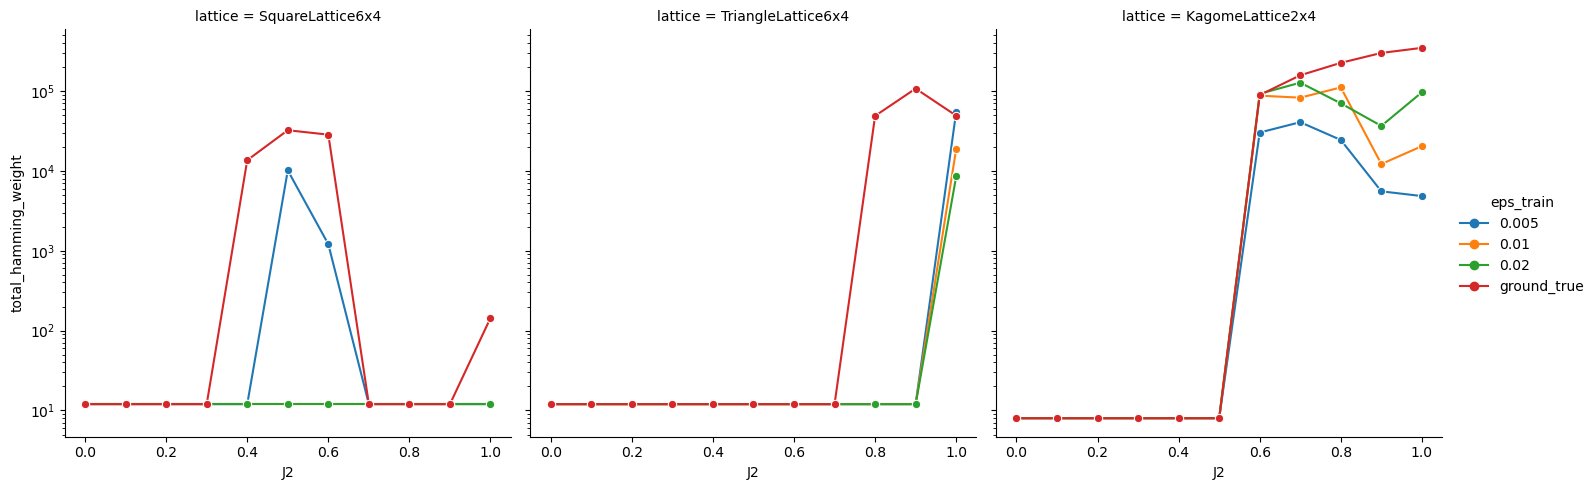

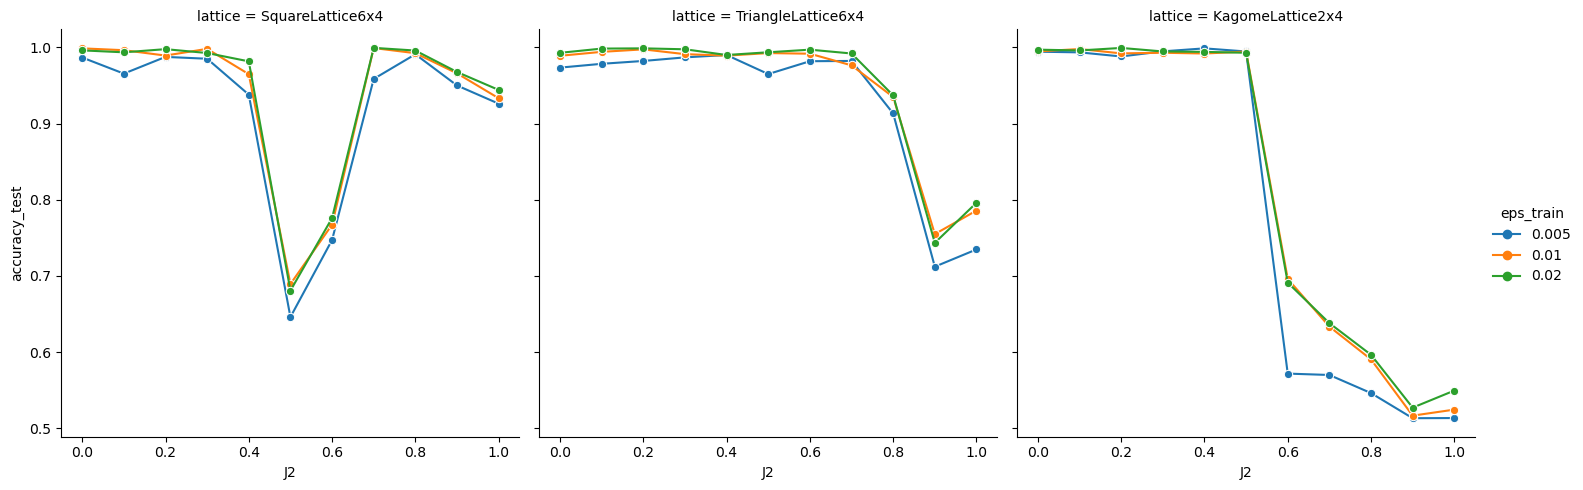

In [42]:
sns.relplot(
    terms.assign(mean_hamming_weight=lambda df: df['total_hamming_weight'] / df['terms']),
    x="J2",
    y="total_hamming_weight",
    col="lattice",
    hue='eps_train',
    # hue="signal_kind",
    kind="line",
    style='eps_train',
    dashes=False,
    markers=["o"],
).set(yscale="log")

sns.relplot(
    model_evaluation.assign(eps_train=lambda df: df['eps_train'].astype('str')),
    x="J2",
    y="accuracy_test",
    col="lattice",
    hue="eps_train",
    kind="line",
    style="eps_train",
    dashes=False,
    markers=["o"],
)


In [45]:
nn_terms

,f1,sign_overlap,accuracy,success,terms,total_hamming_weight,rel_fourier_weight,largest_terms,largest_coeffs,lattice,J2,eps_train
0,0.782205,0.900776,0.800004,True,1559,10122,0.199774,"[5921382, 10855833, 16777215, 0, 1, 16777214, ...","[311.267578125, 311.267578125, -53.0419921875,...",SquareLattice6x4,0.5,0.005
1,0.983454,0.889582,0.983644,True,1,12,0.150808,[10855833],[638.59814453125],TriangleLattice6x4,0.4,0.010
2,0.990527,0.920337,0.990576,True,1,12,0.155162,[10855833],[647.75146484375],SquareLattice6x4,0.4,0.020
3,0.828022,0.451951,0.800007,True,6026,24356,0.182387,"[16777215, 0, 16777207, 8, 16777211, 4, 256, 1...","[82.005859375, 82.005859375, 61.2744140625, 61...",KagomeLattice2x4,0.8,0.005
4,0.998302,0.998795,0.998305,True,1,8,0.160089,[16608090],[-657.9560546875],KagomeLattice2x4,0.2,0.020
...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.963889,0.973657,0.964082,True,1,12,0.138855,[10855833],[612.76904296875],TriangleLattice6x4,0.0,0.005
95,0.997749,0.881698,0.997747,True,1,12,0.159731,[11184844],[657.21923828125],SquareLattice6x4,0.7,0.010
96,0.996708,0.788943,0.996697,True,1,12,0.159058,[10855833],[655.83349609375],TriangleLattice6x4,0.1,0.020
97,0.954614,0.940398,0.954904,True,1,12,0.133417,[10855833],[600.64990234375],TriangleLattice6x4,0.5,0.005


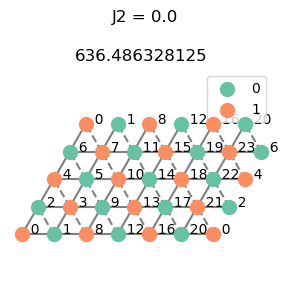

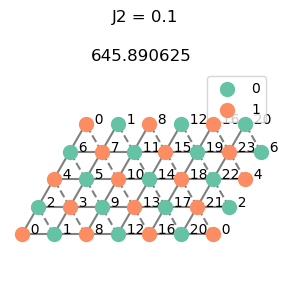

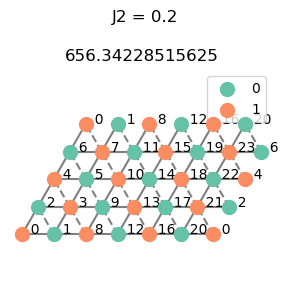

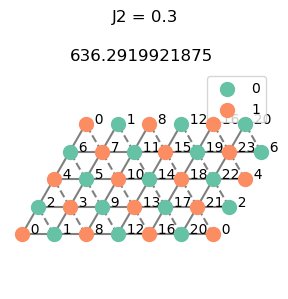

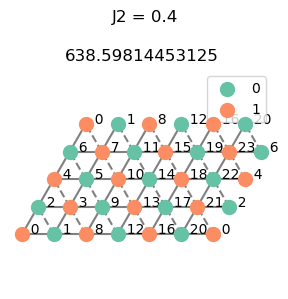

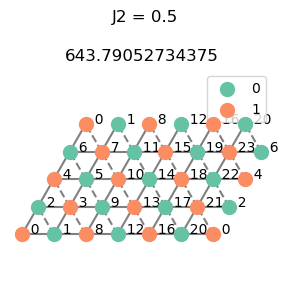

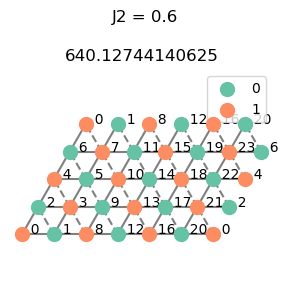

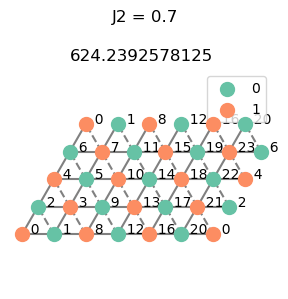

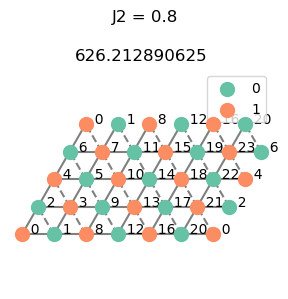

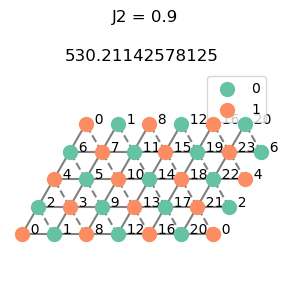

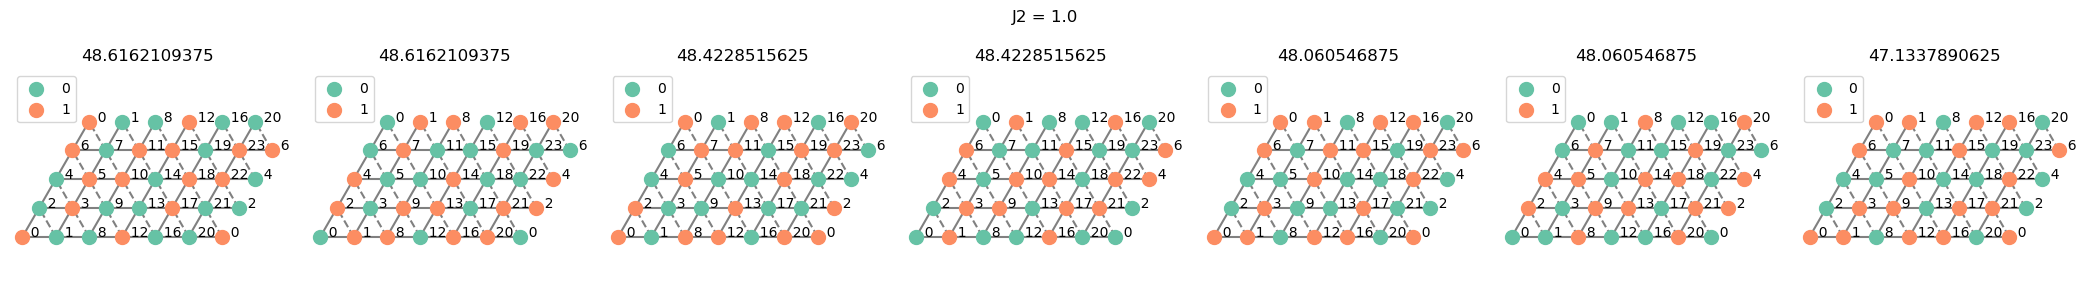

In [55]:
lattice_name = "TriangleLattice6x4"
eps_train = 0.01
max_terms = 7
for _, row in (
    nn_terms.query("lattice == @lattice_name and eps_train == @eps_train").sort_values("J2").iterrows()
):
    J2 = row["J2"]
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = name_to_lattice[lattice_name].plot_subsets(subsets[:max_terms], coeffs[:max_terms])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()


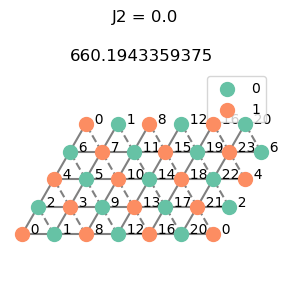

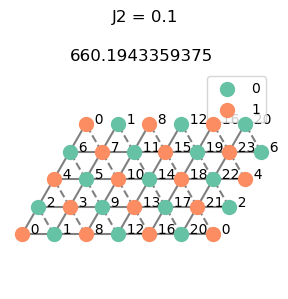

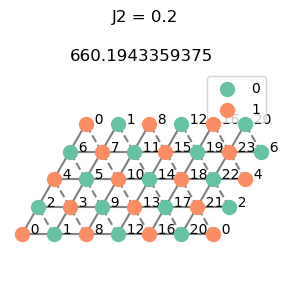

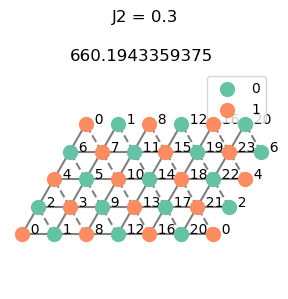

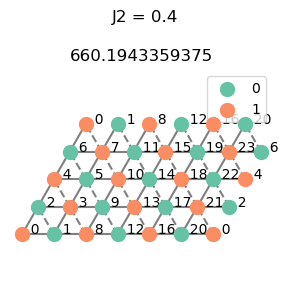

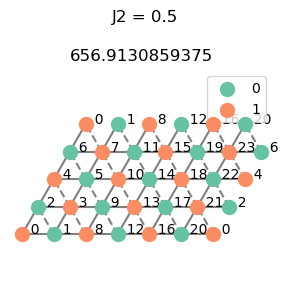

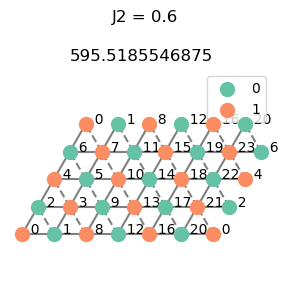

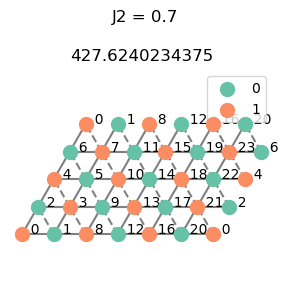

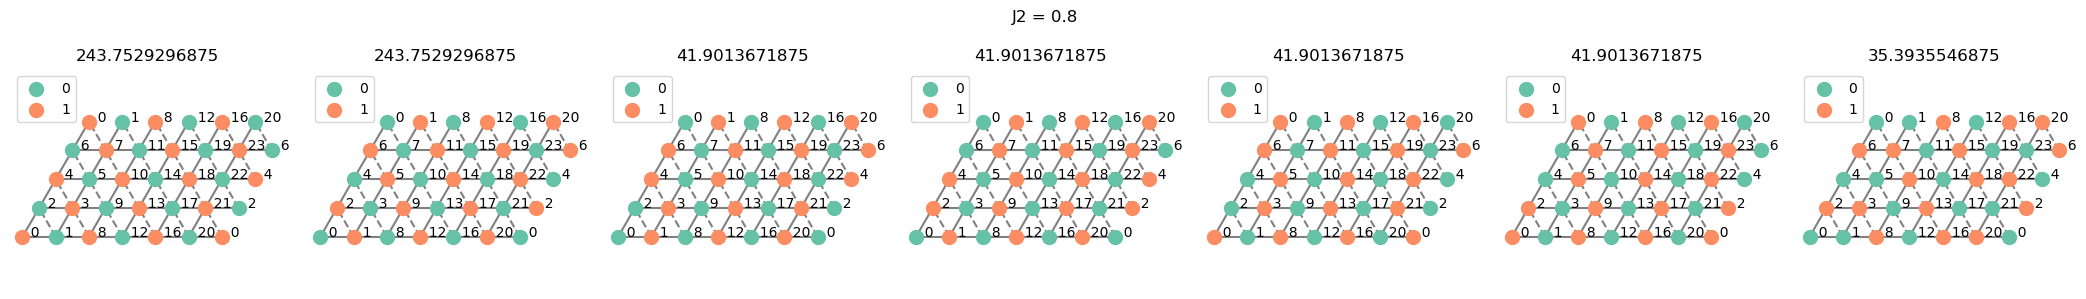

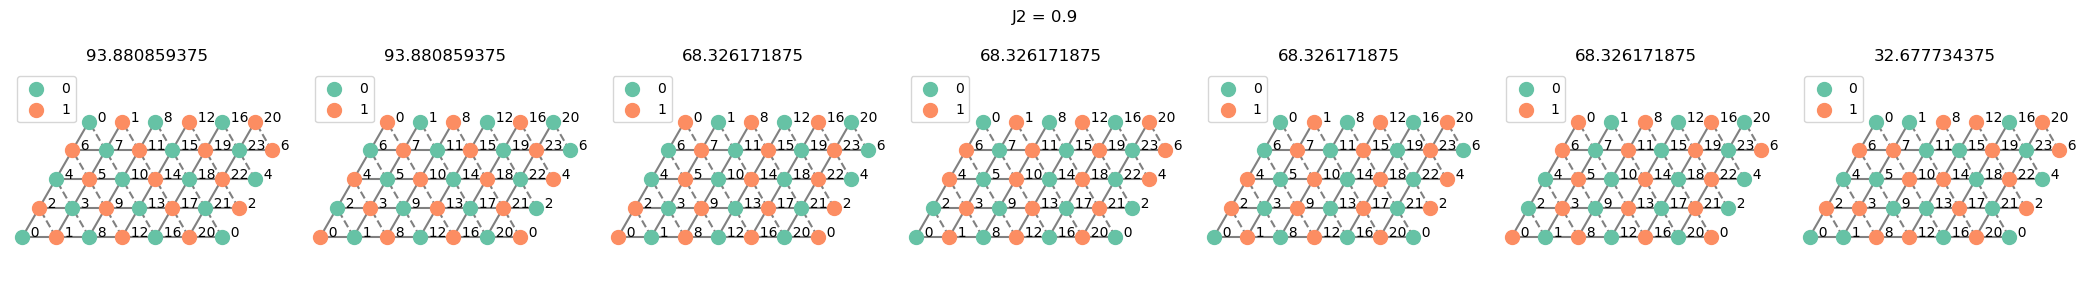

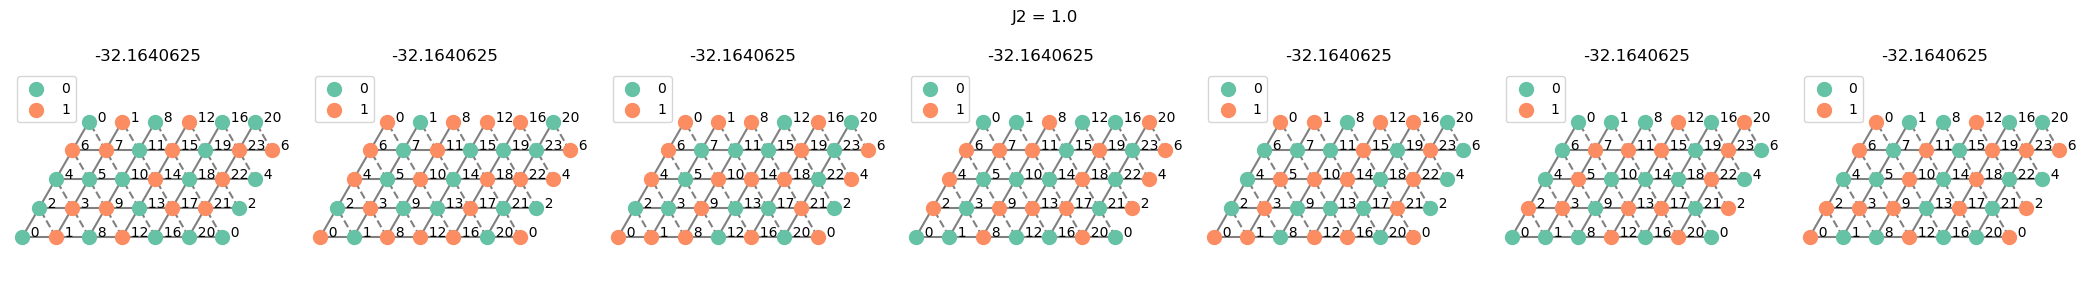

In [56]:
lattice_name = "TriangleLattice6x4"
max_terms = 7
for _, row in (
    system_terms.query("lattice == @lattice_name").sort_values("J2").iterrows()
):
    J2 = row["J2"]
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = name_to_lattice[lattice_name].plot_subsets(subsets[:max_terms], coeffs[:max_terms])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()
